In [47]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.datasets import load_diabetes, make_regression
from sklearn.preprocessing import StandardScaler


In [44]:
x, y = make_regression(n_samples=40, n_features=1, noise=20)

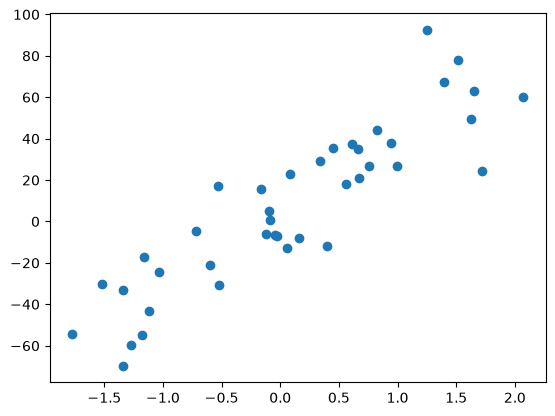

In [45]:
plt.scatter(x,y)

In [50]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.5, random_state=42)   
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

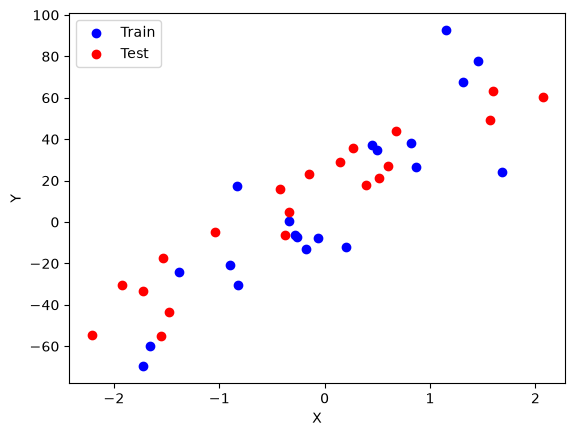

In [51]:
plt.scatter(x_train, y_train, c='blue', label='Train')
plt.scatter(x_test, y_test, c='red', label='Test')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()

In [73]:
model = Sequential()
model.add(Dense(128, input_dim=1, activation='relu'))
model.add(Dense(128, activation='relu'))
model.add(Dense(1, activation='linear'))

adam = Adam(learning_rate=0.01)
model.compile(loss='mse', optimizer=adam, metrics=['mse'])

history = model.fit(x_train, y_train, epochs=1000, validation_data=(x_test, y_test), verbose=0)

/workspaces/Deep-Learning/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [74]:
_, train_mse = model.evaluate(x_train, y_train, verbose=0)
_, test_mse = model.evaluate(x_test, y_test, verbose=0)

print("Train: {}, Test: {}".format(train_mse, test_mse))

Train: 147.8284149169922, Test: 1030.819580078125


In [75]:
k= sorted(model.predict(x_test).flatten())
print(k)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
[np.float32(-135.51215), np.float32(-96.72126), np.float32(-69.10307), np.float32(-45.160408), np.float32(-42.357265), np.float32(-35.618965), np.float32(-16.347979), np.float32(-16.123863), np.float32(-8.8331175), np.float32(-3.5771534), np.float32(-3.3351762), np.float32(-3.2013195), np.float32(6.5605993), np.float32(11.922756), np.float32(22.131046), np.float32(30.410688), np.float32(35.96978), np.float32(40.766495), np.float32(40.878517), np.float32(45.957016)]


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


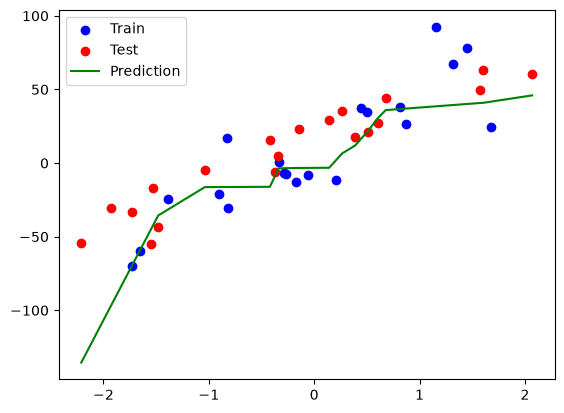

In [78]:
plt.figure()
plt.scatter(x_train, y_train, c='blue', label='Train')
plt.scatter(x_test, y_test, c='red', label='Test')
plt.plot(sorted(x_test), sorted(model.predict(x_test).flatten()), c='green', label='Prediction')
plt.legend()
plt.show()

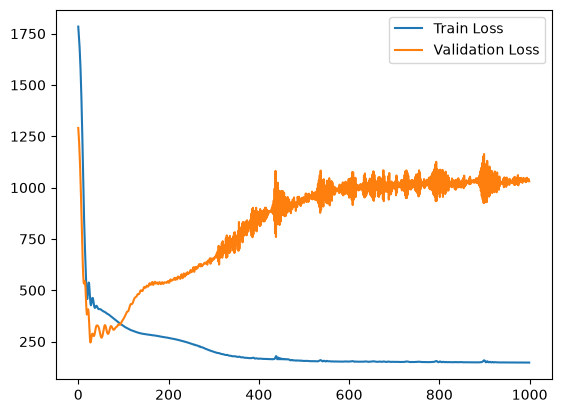

In [80]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.show()

<h1>DropOut Model</h1>

In [87]:
model = Sequential()
model.add(Dense(128, activation='relu', input_shape=(1,)))
model.add(Dropout(0.5))
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(1, activation='linear'))

adam = Adam(learning_rate=0.01)
model.compile(loss='mse', optimizer=adam, metrics=['mse'])

history = model.fit(x_train, y_train, epochs=500, validation_data=(x_test, y_test), verbose=0)

In [85]:
_, train_mse = model.evaluate(x_train, y_train, verbose=0)
_, test_mse = model.evaluate(x_test, y_test, verbose=0)
print(f"Train MSE: {train_mse}")
print(f"Test MSE: {test_mse}")

Train MSE: 224.1242218017578
Test MSE: 497.44134521484375


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


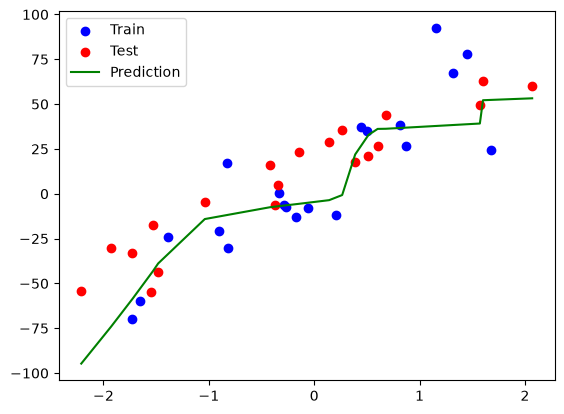

In [86]:
plt.figure()
plt.scatter(x_train, y_train, c='blue', label='Train')
plt.scatter(x_test, y_test, c='red', label='Test')
plt.plot(sorted(x_test), sorted(model.predict(x_test).flatten()), c='green', label='Prediction')
plt.legend()
plt.show()